<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week13/day3-4/Insights_Bert_Daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
# install deps (Colab only)
!pip uninstall -y hf_xet -q
!pip install -q -U transformers datasets huggingface_hub accelerate evaluate

import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


## 1. Load tweet_eval sentiment data

In [2]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

from datasets import load_dataset
raw = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
labels = raw["train"].features["label"].names
print("Labels:", labels)  # should be 3: negative, neutral, positive

Labels: ['negative', 'neutral', 'positive']


In [4]:
import pandas as pd
counts = pd.Series(raw["train"]["label"]).value_counts().sort_index()
counts.index = labels
print(counts)  # class balance

negative     7093
neutral     20673
positive    17849
Name: count, dtype: int64


In [5]:
examples = {l: [] for l in labels}
for row in raw["train"]:
    name = labels[row["label"]]
    if len(examples[name]) < 2:
        examples[name].append(row["text"])
    if all(len(v) == 2 for v in examples.values()):
        break

print(examples)  # 2 tweets per label, saved for later

{'negative': ['So disappointed in wwe summerslam! I want to see john cena wins his 16th title', 'That sucks if you have to take the SATs tomorrow'], 'neutral': ['"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.'], 'positive': ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"']}


## 2. Tokenization

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print(tokenizer("hello world"))  # sanity check

{'input_ids': [101, 7592, 2088, 102], 'token_type_ids': [0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1]}


In [8]:
def preprocess(batch):
    # truncate/pad to 128, add labels
    out = tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)
    out["labels"] = batch["label"]
    return out

tokenized = raw.map(preprocess, batched=True)
tokenized = tokenized.remove_columns(["text"])
print(tokenized["train"][0].keys())  # check fields exist

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])


In [ ]:
!pip install -q -U datasets

In [9]:
tokenized = tokenized.shuffle(seed=42)
tokenized.set_format("torch")
print(type(tokenized["train"][0]["input_ids"]))  # should be torch.Tensor

<class 'torch.Tensor'>


## Step 3. Fine Tuning

In [10]:
## 3. Fine-tuning setup
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print(model.config.num_labels)  # confirm 3-way head

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


3


In [11]:
import numpy as np
import evaluate

acc = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, y = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=y)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=y, average="macro")["f1"],
    }

In [13]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="./out",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [14]:
trainer.train()  # long-running cell — will print loss/metrics per epoch

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.648512,0.623485,0.718000,0.704893
2,0.458433,0.619213,0.747500,0.731689
3,0.269524,0.786445,0.738000,0.724366


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4278, training_loss=0.4671266920491879, metrics={'train_runtime': 1465.5973, 'train_samples_per_second': 93.371, 'train_steps_per_second': 2.919, 'total_flos': 4531956111832320.0, 'train_loss': 0.4671266920491879, 'epoch': 3.0})

In [15]:
trainer.save_model("./best_model")
tokenizer.save_pretrained("./best_model")
print("saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved


## Step 4. Evaluation

In [16]:
## 4. Evaluation & calibration
val_metrics = trainer.evaluate(tokenized["validation"])
print(val_metrics)  # should match epoch 2 numbers above

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.269524,0.619213,3,0.747500,0.731689


{'eval_loss': 0.6192125082015991, 'eval_accuracy': 0.7475, 'eval_f1_macro': 0.7316885964912281}


In [17]:
import torch.nn.functional as F

test_out = trainer.predict(tokenized["test"])
probs = F.softmax(torch.tensor(test_out.predictions), dim=-1).numpy()

preds = probs.argmax(axis=-1)
confidence = probs[range(len(probs)), preds]  # softmax score of the predicted class

test_acc = acc.compute(predictions=preds, references=test_out.label_ids)
test_f1 = f1.compute(predictions=preds, references=test_out.label_ids, average="macro")
print("Test accuracy:", test_acc["accuracy"])
print("Test F1 macro:", test_f1["f1"])

Test accuracy: 0.6851188537935526
Test F1 macro: 0.6837001979177447


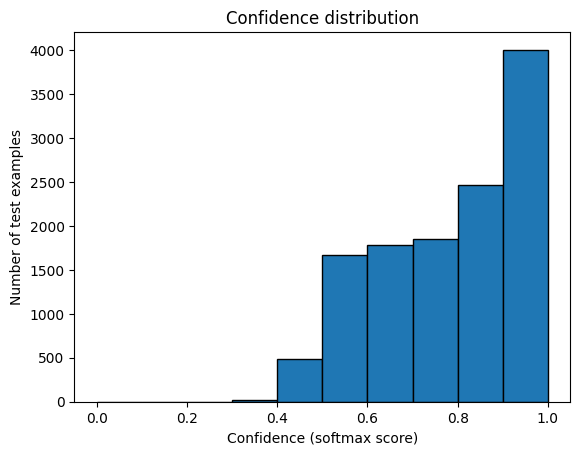

Mean confidence: 0.78324765
Test accuracy:   0.6851188537935526


In [18]:
import matplotlib.pyplot as plt

bins = [i/10 for i in range(11)]  # 0.0, 0.1, ..., 1.0
plt.hist(confidence, bins=bins, edgecolor="black")
plt.xlabel("Confidence (softmax score)")
plt.ylabel("Number of test examples")
plt.title("Confidence distribution")
plt.show()

print("Mean confidence:", confidence.mean())
print("Test accuracy:  ", test_acc["accuracy"])

## Step 5. Attention Inspection

In [19]:
## 5. Attention inspection
from transformers import AutoModel

base_model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)
base_model.eval()
print("loaded")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded


In [20]:
example_text = examples["negative"][0]
print("Example:", example_text)

inputs = tokenizer(example_text, return_tensors="pt", truncation=True, max_length=128)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = base_model(**inputs)

print("Number of layers of attention:", len(outputs.attentions))
print("Shape of last layer attention:", outputs.attentions[-1].shape)

Example: So disappointed in wwe summerslam! I want to see john cena wins his 16th title
Number of layers of attention: 6
Shape of last layer attention: torch.Size([1, 12, 20, 20])


In [21]:
last_layer_attn = outputs.attentions[-1][0]      # drop batch dim -> (12 heads, 20, 20)
avg_attn = last_layer_attn.mean(dim=0)           # average over heads -> (20, 20)

cls_attention = avg_attn[0].numpy()              # row 0 = attention FROM [CLS] TO each token

for tok, score in zip(tokens, cls_attention):
    print(f"{tok:>12s}  {score:.4f}")

       [CLS]  0.0637
          so  0.0396
disappointed  0.0326
          in  0.0237
         wwe  0.0536
     summers  0.0165
       ##lam  0.0470
           !  0.0556
           i  0.0628
        want  0.0352
          to  0.0228
         see  0.0244
        john  0.0120
          ce  0.0084
        ##na  0.0297
        wins  0.0247
         his  0.0175
        16th  0.0259
       title  0.0719
       [SEP]  0.3325


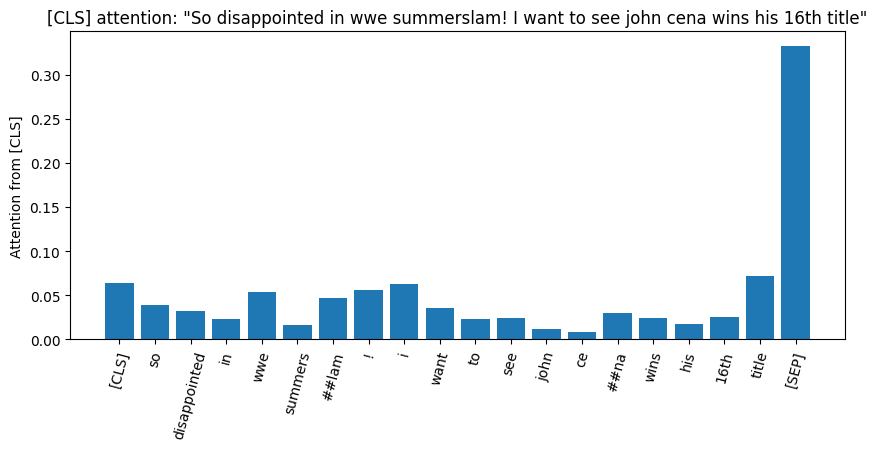

In [22]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(tokens)), cls_attention)
plt.xticks(range(len(tokens)), tokens, rotation=75)
plt.ylabel("Attention from [CLS]")
plt.title(f'[CLS] attention: "{example_text}"')
plt.show()

## Insight
[CLS] attention is dominated by [SEP] (0.33), a known BERT-family
attention-sink pattern. Among content words, "want", "so", and
"disappointed" get the most attention — consistent with the negative label.

In [24]:
device = trainer.model.device
base_model = base_model.to(device)
print("device:", device)

device: cuda:0


In [25]:
## 6. Explainable inference helper
def analyze_text(text, top_k=5):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        clf_logits = trainer.model(**inputs).logits
        probs = F.softmax(clf_logits, dim=-1)[0]
        pred_idx = int(probs.argmax())

        enc_out = base_model(**inputs)
        attn = enc_out.attentions[-1][0].mean(dim=0)[0]

    toks = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    pairs = [(t, s.item()) for t, s in zip(toks, attn) if t not in ("[CLS]", "[SEP]", "[PAD]")]
    pairs.sort(key=lambda p: p[1], reverse=True)

    return {
        "label": label_names[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "highlighted_tokens": [t for t, _ in pairs[:top_k]],
    }

print(analyze_text(example_text))

{'label': 'negative', 'confidence': 0.9458, 'highlighted_tokens': ['title', 'i', '!', 'wwe', '##lam']}


In [26]:
for label_name, tweets in examples.items():
    result = analyze_text(tweets[0])
    print("input   :", tweets[0])
    print("expected:", label_name)
    print("result  :", result)
    print()

input   : So disappointed in wwe summerslam! I want to see john cena wins his 16th title
expected: negative
result  : {'label': 'negative', 'confidence': 0.9458, 'highlighted_tokens': ['title', 'i', '!', 'wwe', '##lam']}

input   : "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
expected: neutral
result  : {'label': 'neutral', 'confidence': 0.9769, 'highlighted_tokens': [')', '"', '"', 'thursday', 'remains']}

input   : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
expected: positive
result  : {'label': 'positive', 'confidence': 0.918, 'highlighted_tokens': ['"', '"', '.', ',', '#']}

